In [38]:
!pip install mlflow dagshub -q

## Imports

In [39]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

mlflow.set_experiment("DLinear_Training")

BASE = '/kaggle/input/datasets/elenejobava/walmart-features-engineered/'

train_fe = pd.read_parquet(BASE + 'train_features.parquet')
test_fe  = pd.read_parquet(BASE + 'test_features.parquet')

with open(BASE + 'feature_cols.json') as f:
    feature_cols = json.load(f)

train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"]  = pd.to_datetime(test_fe["Date"])

print("Train:", train_fe.shape, train_fe["Date"].min(), "->", train_fe["Date"].max())
print("Test :", test_fe.shape,  test_fe["Date"].min(),  "->", test_fe["Date"].max())
print("Num feature_cols saved:", len(feature_cols))

n_series_train = train_fe.groupby(["Store", "Dept"]).ngroups
n_series_test  = test_fe.groupby(["Store", "Dept"]).ngroups
print("Unique Store-Dept series in train:", n_series_train)
print("Unique Store-Dept series in test :", n_series_test)

HORIZON = test_fe["Date"].nunique()
print("Forecast horizon (# unique weeks in test):", HORIZON)

sample_series = train_fe[(train_fe.Store == 1) & (train_fe.Dept == 1)].sort_values("Date")
gaps = sample_series["Date"].diff().dt.days.dropna().unique()
print("Date gaps (days) in a sample series (should all be 7):", gaps)

print("\nColumns:", list(train_fe.columns))

Device: cuda
Train: (421570, 61) 2010-02-05 00:00:00 -> 2012-10-26 00:00:00
Test : (115064, 60) 2012-11-02 00:00:00 -> 2013-07-26 00:00:00
Num feature_cols saved: 57
Unique Store-Dept series in train: 3331
Unique Store-Dept series in test : 3169
Forecast horizon (# unique weeks in test): 39
Date gaps (days) in a sample series (should all be 7): [7.]

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'any_markdown', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter', 'Year_norm', 'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos', 'weeks_to_SuperBowl', 'near_SuperBowl', 'weeks_to_LaborDay', 'near_LaborDay', 'weeks_to_Thanksgiving', 'near_Thanksgiving', 'weeks_to_Christmas', 'near_Christmas', 'is_super_bowl', 'is_labor_day', 'is_thanksgiving', 'is_christmas', 'weeks_to_Easter', 'near_Easter', 'is_easter', 'before_Easter', 'Type_enc', 'Size_log', 'S

In [40]:
import logging
logging.getLogger("mlflow.pytorch").setLevel(logging.ERROR)
logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)

In [41]:
import dagshub

dagshub.init(repo_owner='ejoba22', repo_name='walmart-sales-forecasting', mlflow=True)

mlflow.set_experiment("DLinear_Training")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("DLinear_Training"))

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

Tracking URI: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow
Active experiment: <Experiment: artifact_location='mlflow-artifacts:/bfb225c938c44047a06e7f2f2fe2fd44', creation_time=1783709402399, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1783709402399, lifecycle_stage='active', name='DLinear_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>


## 2. Series Structure & Window Parameters

Series length stats (weeks per Store-Dept in train):
count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64

Percentiles:
0.01      1.0
0.05     10.0
0.10     48.0
0.25    143.0
0.50    143.0
dtype: float64

Series with any gap > 7 days: 605 out of 3331

Train->Test gap per series (days) - should mostly be 7:
gap_days
7     2920
14      29
21      28
28      19
42      11
Name: count, dtype: int64

Series with < 52 weeks of history: 340 / 3331
Series with < 26 weeks of history: 272 / 3331


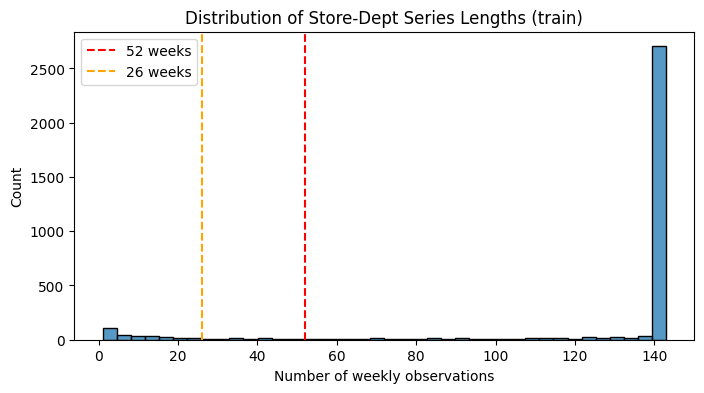


Store-Dept pairs in test with NO train history at all: 11


In [42]:
series_lengths = train_fe.groupby(["Store", "Dept"]).size()
print("Series length stats (weeks per Store-Dept in train):")
print(series_lengths.describe())
print("\nPercentiles:")
print(series_lengths.quantile([0.01, 0.05, 0.10, 0.25, 0.5]))

def max_gap_days(g):
    d = g.sort_values("Date")["Date"].diff().dt.days.dropna()
    return d.max() if len(d) else np.nan

gap_check = train_fe.groupby(["Store", "Dept"]).apply(max_gap_days, include_groups=False)
print("\nSeries with any gap > 7 days:", (gap_check > 7).sum(), "out of", len(gap_check))

train_last_date = train_fe.groupby(["Store", "Dept"])["Date"].max().rename("train_last")
test_first_date  = test_fe.groupby(["Store", "Dept"])["Date"].min().rename("test_first")
merged = pd.concat([train_last_date, test_first_date], axis=1).dropna()
merged["gap_days"] = (merged["test_first"] - merged["train_last"]).dt.days
print("\nTrain->Test gap per series (days) - should mostly be 7:")
print(merged["gap_days"].value_counts().head())

short_series = (series_lengths < 52).sum()
print(f"\nSeries with < 52 weeks of history: {short_series} / {len(series_lengths)}")
short_series_26 = (series_lengths < 26).sum()
print(f"Series with < 26 weeks of history: {short_series_26} / {len(series_lengths)}")

plt.figure(figsize=(8, 4))
sns.histplot(series_lengths, bins=40)
plt.axvline(52, color='red', linestyle='--', label='52 weeks')
plt.axvline(26, color='orange', linestyle='--', label='26 weeks')
plt.title("Distribution of Store-Dept Series Lengths (train)")
plt.xlabel("Number of weekly observations")
plt.legend()
plt.show()

train_pairs = set(zip(train_fe.Store, train_fe.Dept))
test_pairs  = set(zip(test_fe.Store, test_fe.Dept))
new_in_test = test_pairs - train_pairs
print(f"\nStore-Dept pairs in test with NO train history at all: {len(new_in_test)}")

## 3. Reindexing to a Continuous Weekly Grid

Full grid length: 182 weeks

Example gappy series: Store 1, Dept 18, 113 raw rows
Reindexed length: 143
Number of filled-in (previously missing) weeks: 30


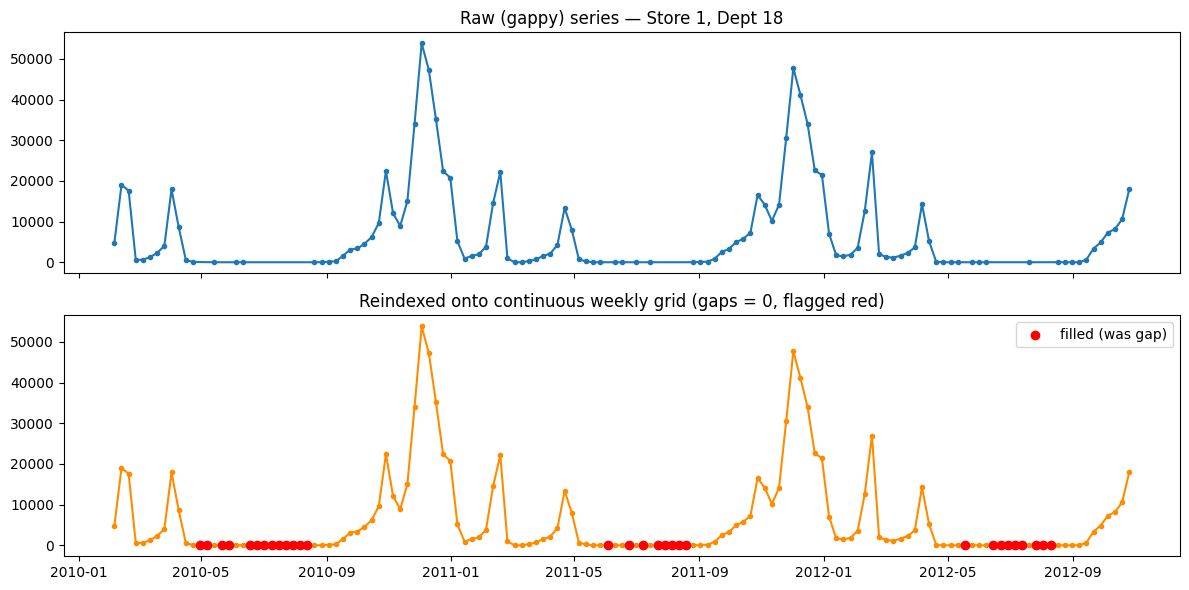


Cold-start Store-Dept pairs (no train history):
[(18, 43), (24, 43), (36, 30), (37, 29), (25, 99), (9, 99), (34, 39), (45, 39), (42, 30), (10, 99), (5, 99)]


In [43]:
full_date_range = pd.date_range(train_fe["Date"].min(), test_fe["Date"].max(), freq="7D")
print("Full grid length:", len(full_date_range), "weeks")

gappy_pair = gap_check[gap_check > 7].index[0]
store_i, dept_i = gappy_pair
example = train_fe[(train_fe.Store == store_i) & (train_fe.Dept == dept_i)].sort_values("Date")
print(f"\nExample gappy series: Store {store_i}, Dept {dept_i}, {len(example)} raw rows")

example_reindexed = (
    example.set_index("Date")["Weekly_Sales"]
    .reindex(full_date_range[full_date_range <= example["Date"].max()])
)
example_reindexed_filled = example_reindexed.fillna(0)
is_active = example_reindexed.notna().astype(int)

print("Reindexed length:", len(example_reindexed))
print("Number of filled-in (previously missing) weeks:", is_active.eq(0).sum())

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(example["Date"], example["Weekly_Sales"], marker='o', markersize=3)
axes[0].set_title(f"Raw (gappy) series — Store {store_i}, Dept {dept_i}")

axes[1].plot(example_reindexed_filled.index, example_reindexed_filled.values, marker='o', markersize=3, color='darkorange')
axes[1].scatter(example_reindexed_filled.index[is_active == 0],
                 example_reindexed_filled.values[is_active == 0],
                 color='red', zorder=5, label='filled (was gap)')
axes[1].set_title("Reindexed onto continuous weekly grid (gaps = 0, flagged red)")
axes[1].legend()
plt.tight_layout()
plt.show()

cold_start_pairs = list(new_in_test)
print("\nCold-start Store-Dept pairs (no train history):")
print(cold_start_pairs)

## 4. Full Panel Construction

In [44]:
full_date_range = pd.date_range(train_fe["Date"].min(), test_fe["Date"].max(), freq="7D")

calendar_cols = [
    'IsHoliday', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter', 'Year_norm',
    'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos',
    'weeks_to_SuperBowl', 'near_SuperBowl', 'before_SuperBowl',
    'weeks_to_LaborDay', 'near_LaborDay', 'before_LaborDay',
    'weeks_to_Thanksgiving', 'near_Thanksgiving', 'before_Thanksgiving',
    'weeks_to_Christmas', 'near_Christmas', 'before_Christmas',
    'is_super_bowl', 'is_labor_day', 'is_thanksgiving', 'is_christmas'
]
macro_cols = ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
              'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'any_markdown',
              'total_markdown', 'active_markdown_count', 'markdown_x_holiday']
store_cols = ['Type_enc', 'Size_log']

store_covariates = pd.concat([
    train_fe[['Store', 'Date'] + calendar_cols + macro_cols + store_cols],
    test_fe[['Store', 'Date'] + calendar_cols + macro_cols + store_cols]
], axis=0).drop_duplicates(subset=['Store', 'Date']).sort_values(['Store', 'Date'])

print("Store covariate table shape:", store_covariates.shape)
print("Any nulls in covariate table:\n", store_covariates.isnull().sum()[store_covariates.isnull().sum() > 0])

train_pairs_all = set(zip(train_fe.Store, train_fe.Dept))
test_pairs_all  = set(zip(test_fe.Store, test_fe.Dept))
cold_start_pairs = list(test_pairs_all - train_pairs_all)
active_pairs = sorted(train_pairs_all | test_pairs_all - set(cold_start_pairs))

print("Total Store-Dept pairs to model with DLinear:", len(active_pairs))
print("Cold-start pairs set aside for fallback:", len(cold_start_pairs))

target_rows = []
for store_i, dept_i in active_pairs:
    series_dates = full_date_range
    obs = train_fe[(train_fe.Store == store_i) & (train_fe.Dept == dept_i)][['Date', 'Weekly_Sales']]
    obs = obs.set_index('Date').reindex(series_dates)
    obs['Store'] = store_i
    obs['Dept'] = dept_i
    obs['is_active'] = obs['Weekly_Sales'].notna().astype(int)
    obs['Weekly_Sales'] = obs['Weekly_Sales'].fillna(0)
    obs = obs.reset_index().rename(columns={'index': 'Date'})
    target_rows.append(obs)

target_panel = pd.concat(target_rows, axis=0, ignore_index=True)
print("\nTarget panel shape:", target_panel.shape)
print("Expected:", len(active_pairs) * len(full_date_range))

full_panel = target_panel.merge(store_covariates, on=['Store', 'Date'], how='left')
print("\nFull panel shape:", full_panel.shape)
print("Nulls after covariate merge:\n", full_panel.isnull().sum()[full_panel.isnull().sum() > 0])

Store covariate table shape: (8190, 44)
Any nulls in covariate table:
 Series([], dtype: int64)
Total Store-Dept pairs to model with DLinear: 3331
Cold-start pairs set aside for fallback: 11

Target panel shape: (606242, 5)
Expected: 606242

Full panel shape: (606242, 47)
Nulls after covariate merge:
 Series([], dtype: int64)


## 5. Cross-Validation Strategy Rolling-Origin, Time-Based

CV fold (val_start, val_end) week indices on the 182-week grid:
  Fold 0: train < week 104, validate on weeks [104, 117)
  Fold 1: train < week 117, validate on weeks [117, 130)
  Fold 2: train < week 130, validate on weeks [130, 143)


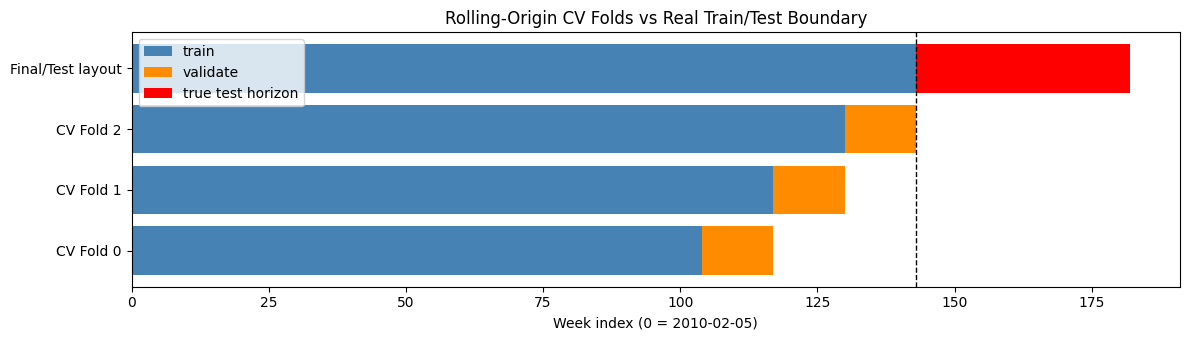


Minimum available lookback at earliest fold's val_start (104 weeks): 104 weeks of history (need 52, rest will be zero-padded+masked)


In [45]:
TRAIN_WEEKS = 143
TEST_HORIZON = 39
LOOKBACK = 52
CV_FOLD_HORIZON = 13
N_CV_FOLDS = 3

fold_cutoffs = []
for i in range(N_CV_FOLDS):
    val_end = TRAIN_WEEKS - (N_CV_FOLDS - 1 - i) * CV_FOLD_HORIZON
    val_start = val_end - CV_FOLD_HORIZON
    fold_cutoffs.append((val_start, val_end))

print("CV fold (val_start, val_end) week indices on the 182-week grid:")
for i, (vs, ve) in enumerate(fold_cutoffs):
    print(f"  Fold {i}: train < week {vs}, validate on weeks [{vs}, {ve})")

fig, ax = plt.subplots(figsize=(12, 3.5))
for i, (vs, ve) in enumerate(fold_cutoffs):
    ax.barh(i, vs, left=0, color='steelblue', label='train' if i == 0 else None)
    ax.barh(i, ve - vs, left=vs, color='darkorange', label='validate' if i == 0 else None)

ax.barh(N_CV_FOLDS, TRAIN_WEEKS, left=0, color='steelblue')
ax.barh(N_CV_FOLDS, TEST_HORIZON, left=TRAIN_WEEKS, color='red', label='true test horizon')

ax.axvline(TRAIN_WEEKS, color='black', linestyle='--', linewidth=1)
ax.set_yticks(list(range(N_CV_FOLDS + 1)))
ax.set_yticklabels([f"CV Fold {i}" for i in range(N_CV_FOLDS)] + ["Final/Test layout"])
ax.set_xlabel("Week index (0 = 2010-02-05)")
ax.set_title("Rolling-Origin CV Folds vs Real Train/Test Boundary")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"\nMinimum available lookback at earliest fold's val_start ({fold_cutoffs[0][0]} weeks): "
      f"{fold_cutoffs[0][0]} weeks of history (need {LOOKBACK}, rest will be zero-padded+masked)")

## 6. Windowing Dataset

In [46]:
KNOWN_COVARIATE_COLS = calendar_cols

class WalmartWindowDataset(Dataset):
    def __init__(self, panel, active_pairs, cutoff_week, lookback, horizon, covariate_cols):
        self.lookback = lookback
        self.horizon = horizon
        self.covariate_cols = covariate_cols
        self.samples = []

        panel_indexed = panel.set_index(['Store', 'Dept'])

        for store_i, dept_i in active_pairs:
            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            if cutoff_week + horizon > len(series):
                continue

            past = series.iloc[max(0, cutoff_week - lookback):cutoff_week]
            future = series.iloc[cutoff_week:cutoff_week + horizon]

            past_target = past['Weekly_Sales'].values.astype(np.float32)
            past_mask = past['is_active'].values.astype(np.float32)
            pad_len = lookback - len(past_target)
            if pad_len > 0:
                past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])
                past_mask = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_mask])

            future_target = future['Weekly_Sales'].values.astype(np.float32)
            future_mask = future['is_active'].values.astype(np.float32)
            future_holiday_weight = np.where(future['IsHoliday'].values.astype(bool), 5.0, 1.0).astype(np.float32)

            past_cov = past[self.covariate_cols].values.astype(np.float32)
            if pad_len > 0:
                past_cov = np.concatenate([np.zeros((pad_len, past_cov.shape[1]), dtype=np.float32), past_cov], axis=0)
            future_cov = future[self.covariate_cols].values.astype(np.float32)

            self.samples.append({
                'store': store_i,
                'dept': dept_i,
                'past_target': past_target,
                'past_mask': past_mask,
                'past_cov': past_cov,
                'future_cov': future_cov,
                'future_target': future_target,
                'future_mask': future_mask,
                'future_weight': future_holiday_weight,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            'past_target': torch.from_numpy(s['past_target']),
            'past_mask': torch.from_numpy(s['past_mask']),
            'past_cov': torch.from_numpy(s['past_cov']),
            'future_cov': torch.from_numpy(s['future_cov']),
            'future_target': torch.from_numpy(s['future_target']),
            'future_mask': torch.from_numpy(s['future_mask']),
            'future_weight': torch.from_numpy(s['future_weight']),
        }

fold0_val_start, fold0_val_end = fold_cutoffs[0]
train_ds_fold0 = WalmartWindowDataset(full_panel, active_pairs, fold0_val_start, LOOKBACK, CV_FOLD_HORIZON, KNOWN_COVARIATE_COLS)
val_ds_fold0   = WalmartWindowDataset(full_panel, active_pairs, fold0_val_start, LOOKBACK, CV_FOLD_HORIZON, KNOWN_COVARIATE_COLS)

print("Fold 0 dataset size:", len(train_ds_fold0))

sample = train_ds_fold0[0]
for k, v in sample.items():
    print(k, v.shape, v.dtype)

Fold 0 dataset size: 3331
past_target torch.Size([52]) torch.float32
past_mask torch.Size([52]) torch.float32
past_cov torch.Size([52, 27]) torch.float32
future_cov torch.Size([13, 27]) torch.float32
future_target torch.Size([13]) torch.float32
future_mask torch.Size([13]) torch.float32
future_weight torch.Size([13]) torch.float32


## 7. DLinear Model

In [47]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, self.kernel_size - 1 - (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)
        return x

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

class DLinear(nn.Module):
    def __init__(self, lookback, horizon, n_covariates, kernel_size=13, individual=False):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.decomp = SeriesDecomposition(kernel_size)
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend = nn.Linear(lookback, horizon)
        self.covariate_proj = nn.Linear(n_covariates, 1) if n_covariates > 0 else None

    def forward(self, past_target, future_cov=None):
        x = past_target.unsqueeze(-1)
        seasonal, trend = self.decomp(x)
        seasonal = seasonal.squeeze(-1)
        trend = trend.squeeze(-1)

        seasonal_out = self.linear_seasonal(seasonal)
        trend_out = self.linear_trend(trend)
        out = seasonal_out + trend_out

        if self.covariate_proj is not None and future_cov is not None:
            cov_effect = self.covariate_proj(future_cov).squeeze(-1)
            out = out + cov_effect

        return out

model = DLinear(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", n_params)

sample_batch = {k: v.unsqueeze(0).to(device) for k, v in sample.items()}
with torch.no_grad():
    out = model(sample_batch['past_target'], sample_batch['future_cov'])
print("Output shape:", out.shape)

DLinear(
  (decomp): SeriesDecomposition(
    (moving_avg): MovingAvg(
      (avg): AvgPool1d(kernel_size=(13,), stride=(1,), padding=(0,))
    )
  )
  (linear_seasonal): Linear(in_features=52, out_features=13, bias=True)
  (linear_trend): Linear(in_features=52, out_features=13, bias=True)
  (covariate_proj): Linear(in_features=27, out_features=1, bias=True)
)
Total trainable parameters: 1406
Output shape: torch.Size([1, 13])


## 8. Multi-Window Training Data + WMAE Loss

In [48]:
class WalmartMultiWindowDataset(Dataset):
    def __init__(self, panel, active_pairs, max_cutoff, lookback, horizon, covariate_cols, stride=4, min_cutoff=None):
        self.samples = []
        panel_indexed = panel.set_index(['Store', 'Dept'])
        min_cutoff = min_cutoff if min_cutoff is not None else lookback + horizon

        for store_i, dept_i in active_pairs:
            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            series_len = len(series)
            # FIX: subtract horizon from max_cutoff so no training window's
            # future can reach into or past the validation split point.
            last_valid_cutoff = min(max_cutoff - horizon, series_len - horizon)

            for cutoff in range(min_cutoff, last_valid_cutoff + 1, stride):
                past = series.iloc[max(0, cutoff - lookback):cutoff]
                future = series.iloc[cutoff:cutoff + horizon]
                if len(future) < horizon:
                    continue

                past_target = past['Weekly_Sales'].values.astype(np.float32)
                past_mask = past['is_active'].values.astype(np.float32)
                pad_len = lookback - len(past_target)
                if pad_len > 0:
                    past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])
                    past_mask = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_mask])

                past_cov = past[covariate_cols].values.astype(np.float32)
                if pad_len > 0:
                    past_cov = np.concatenate([np.zeros((pad_len, past_cov.shape[1]), dtype=np.float32), past_cov], axis=0)
                future_cov = future[covariate_cols].values.astype(np.float32)

                future_target = future['Weekly_Sales'].values.astype(np.float32)
                future_mask = future['is_active'].values.astype(np.float32)
                future_weight = np.where(future['IsHoliday'].values.astype(bool), 5.0, 1.0).astype(np.float32)

                self.samples.append({
                    'past_target': past_target, 'past_mask': past_mask, 'past_cov': past_cov,
                    'future_cov': future_cov, 'future_target': future_target,
                    'future_mask': future_mask, 'future_weight': future_weight,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {k: torch.from_numpy(v) for k, v in s.items()}


def wmae_loss(pred, target, mask, weight):
    combined_weight = mask * weight
    numerator = (combined_weight * torch.abs(pred - target)).sum()
    denominator = combined_weight.sum().clamp(min=1e-6)
    return numerator / denominator


fold0_val_start, fold0_val_end = fold_cutoffs[0]
train_ds_fold0 = WalmartMultiWindowDataset(
    full_panel, active_pairs, max_cutoff=fold0_val_start, lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
)
val_ds_fold0 = WalmartWindowDataset(
    full_panel, active_pairs, cutoff_week=fold0_val_start, lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
)

print("Fold 0 train samples (sliding windows):", len(train_ds_fold0))
print("Fold 0 val samples (one per series):", len(val_ds_fold0))

Fold 0 train samples (sliding windows): 23317
Fold 0 val samples (one per series): 3331


## 9. Training Loop Fold 0 (Baseline Run)

Epoch 1/30 - train_wmae: 5523.63 - val_wmae: 2687.82
Epoch 2/30 - train_wmae: 2542.67 - val_wmae: 2417.45
Epoch 3/30 - train_wmae: 2187.99 - val_wmae: 2217.22
Epoch 4/30 - train_wmae: 1991.91 - val_wmae: 2125.53
Epoch 5/30 - train_wmae: 1858.75 - val_wmae: 1984.07
Epoch 6/30 - train_wmae: 1768.48 - val_wmae: 1895.88
Epoch 7/30 - train_wmae: 1709.19 - val_wmae: 2035.19
Epoch 8/30 - train_wmae: 1668.20 - val_wmae: 1886.73
Epoch 9/30 - train_wmae: 1644.28 - val_wmae: 1893.73
Epoch 10/30 - train_wmae: 1619.73 - val_wmae: 1856.96
Epoch 11/30 - train_wmae: 1613.99 - val_wmae: 1935.26
Epoch 12/30 - train_wmae: 1590.92 - val_wmae: 1849.86
Epoch 13/30 - train_wmae: 1583.70 - val_wmae: 1940.96
Epoch 14/30 - train_wmae: 1576.78 - val_wmae: 1970.66
Epoch 15/30 - train_wmae: 1575.04 - val_wmae: 1960.52
Epoch 16/30 - train_wmae: 1569.09 - val_wmae: 2002.57
Epoch 17/30 - train_wmae: 1571.89 - val_wmae: 1884.58
Epoch 18/30 - train_wmae: 1565.63 - val_wmae: 1894.97
Epoch 19/30 - train_wmae: 1562.86 - v

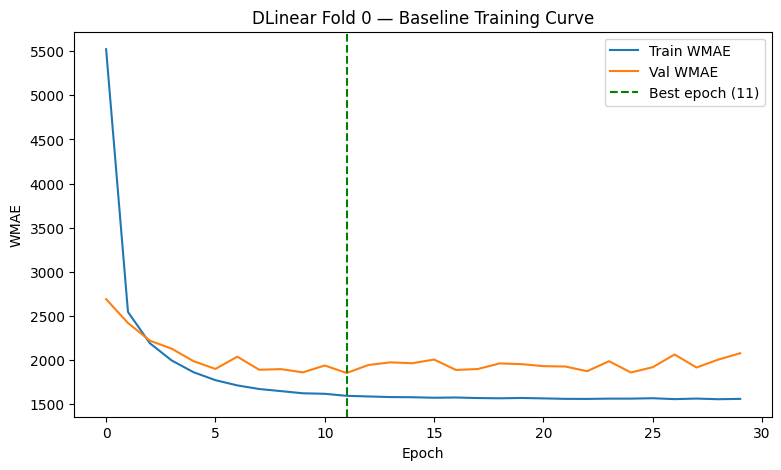

Best val WMAE: 1849.8601211162236 at epoch 11


In [49]:
def collate_fn(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0].keys()}

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_weight = 0.0, 0.0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['past_target'], batch['future_cov'])
            loss = wmae_loss(pred, batch['future_target'], batch['future_mask'], batch['future_weight'])

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_weight = (batch['future_mask'] * batch['future_weight']).sum().item()
            total_loss += loss.item() * batch_weight
            total_weight += batch_weight

    return total_loss / max(total_weight, 1e-6)


BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
KERNEL_SIZE = 13

train_loader = DataLoader(train_ds_fold0, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds_fold0, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = DLinear(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS), kernel_size=KERNEL_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
n_params = sum(p.numel() for p in model.parameters())

example_batch = next(iter(train_loader))
example_past_target = example_batch['past_target'][:1].cpu().numpy()
example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

train_losses, val_losses = [], []
best_val_wmae = float("inf")
best_val_epoch = -1
best_state_dict = None

with mlflow.start_run(run_name="DLinear_Fold0_Baseline"):
    mlflow.set_tags({
        "model_type": "DLinear",
        "fold": "0",
        "run_type": "baseline",
        "device": str(device),
    })

    mlflow.log_params({
        "lookback": LOOKBACK, "horizon": CV_FOLD_HORIZON, "kernel_size": KERNEL_SIZE,
        "batch_size": BATCH_SIZE, "lr": LR, "epochs": EPOCHS, "fold": 0,
        "n_covariates": len(KNOWN_COVARIATE_COLS), "n_params": n_params,
        "individual_weights": False,
    })

    for epoch in range(EPOCHS):
        train_wmae = run_epoch(model, train_loader, optimizer)
        val_wmae = run_epoch(model, val_loader)
        train_losses.append(train_wmae)
        val_losses.append(val_wmae)

        mlflow.log_metric("train_wmae", train_wmae, step=epoch)
        mlflow.log_metric("val_wmae", val_wmae, step=epoch)

        if val_wmae < best_val_wmae:
            best_val_wmae = val_wmae
            best_val_epoch = epoch
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1}/{EPOCHS} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_metric("best_val_epoch", best_val_epoch)
    mlflow.log_metric("final_train_wmae", train_losses[-1])
    mlflow.log_metric("final_val_wmae", val_losses[-1])

    model.load_state_dict(best_state_dict)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_losses, label="Train WMAE")
    ax.plot(val_losses, label="Val WMAE")
    ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("WMAE")
    ax.set_title("DLinear Fold 0 — Baseline Training Curve")
    ax.legend()
    mlflow.log_figure(fig, "loss_curve.png")

    mlflow.pytorch.log_model(
        model,
        name="model",
        serialization_format="pickle",
        input_example=(example_past_target, example_future_cov)
    )

plt.show()
print("Best val WMAE:", best_val_wmae, "at epoch", best_val_epoch)

## 10. Refactored Training Function + Full 3-Fold CV

[DLinear_Fold0_Baseline] Epoch 1/30 - train_wmae: 4341.59 - val_wmae: 2351.48
[DLinear_Fold0_Baseline] Epoch 2/30 - train_wmae: 2512.64 - val_wmae: 2064.41
[DLinear_Fold0_Baseline] Epoch 3/30 - train_wmae: 2155.21 - val_wmae: 1998.75
[DLinear_Fold0_Baseline] Epoch 4/30 - train_wmae: 1963.62 - val_wmae: 1968.08
[DLinear_Fold0_Baseline] Epoch 5/30 - train_wmae: 1842.26 - val_wmae: 1883.81
[DLinear_Fold0_Baseline] Epoch 6/30 - train_wmae: 1764.27 - val_wmae: 1921.71
[DLinear_Fold0_Baseline] Epoch 7/30 - train_wmae: 1704.94 - val_wmae: 1916.37
[DLinear_Fold0_Baseline] Epoch 8/30 - train_wmae: 1673.39 - val_wmae: 1942.89
[DLinear_Fold0_Baseline] Epoch 9/30 - train_wmae: 1644.48 - val_wmae: 1916.26
[DLinear_Fold0_Baseline] Epoch 10/30 - train_wmae: 1612.73 - val_wmae: 1853.74
[DLinear_Fold0_Baseline] Epoch 11/30 - train_wmae: 1611.50 - val_wmae: 1865.25
[DLinear_Fold0_Baseline] Epoch 12/30 - train_wmae: 1593.85 - val_wmae: 1928.69
[DLinear_Fold0_Baseline] Epoch 13/30 - train_wmae: 1584.63 - 

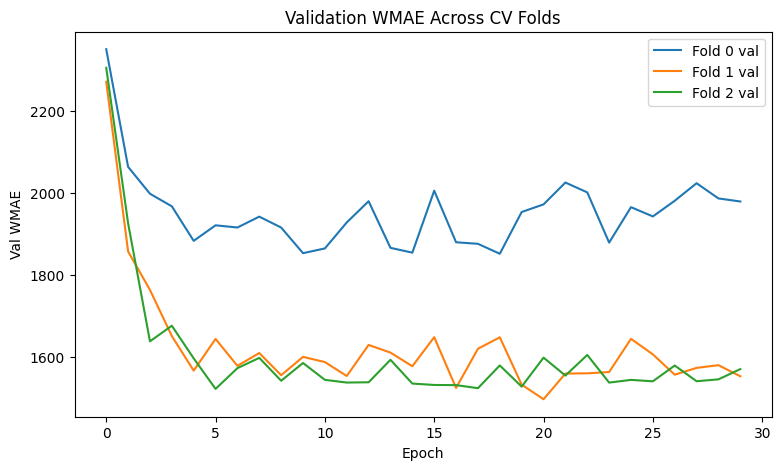

In [50]:
def train_dlinear(train_ds, val_ds, lookback, horizon, n_covariates,
                   kernel_size=13, lr=1e-3, batch_size=256, epochs=30,
                   weight_decay=0.0, individual=False,
                   run_name="DLinear_run", tags=None, log_to_mlflow=True):

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model = DLinear(lookback=lookback, horizon=horizon, n_covariates=n_covariates, kernel_size=kernel_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_params = sum(p.numel() for p in model.parameters())

    example_batch = next(iter(train_loader))
    example_past_target = example_batch['past_target'][:1].cpu().numpy()
    example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

    train_losses, val_losses = [], []
    best_val_wmae = float("inf")
    best_val_epoch = -1
    best_state_dict = None

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else None
    if run_ctx:
        run_ctx.__enter__()

    try:
        if log_to_mlflow:
            mlflow.set_tags(tags or {})
            mlflow.log_params({
                "lookback": lookback, "horizon": horizon, "kernel_size": kernel_size,
                "batch_size": batch_size, "lr": lr, "epochs": epochs,
                "weight_decay": weight_decay, "n_covariates": n_covariates,
                "n_params": n_params, "individual_weights": individual,
            })

        for epoch in range(epochs):
            train_wmae = run_epoch(model, train_loader, optimizer)
            val_wmae = run_epoch(model, val_loader)
            train_losses.append(train_wmae)
            val_losses.append(val_wmae)

            if log_to_mlflow:
                mlflow.log_metric("train_wmae", train_wmae, step=epoch)
                mlflow.log_metric("val_wmae", val_wmae, step=epoch)

            if val_wmae < best_val_wmae:
                best_val_wmae = val_wmae
                best_val_epoch = epoch
                best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

            print(f"[{run_name}] Epoch {epoch+1}/{epochs} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

        model.load_state_dict(best_state_dict)

        if log_to_mlflow:
            mlflow.log_metric("best_val_wmae", best_val_wmae)
            mlflow.log_metric("best_val_epoch", best_val_epoch)
            mlflow.log_metric("final_train_wmae", train_losses[-1])
            mlflow.log_metric("final_val_wmae", val_losses[-1])

            fig, ax = plt.subplots(figsize=(9, 5))
            ax.plot(train_losses, label="Train WMAE")
            ax.plot(val_losses, label="Val WMAE")
            ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
            ax.set_xlabel("Epoch")
            ax.set_ylabel("WMAE")
            ax.set_title(f"{run_name} — Training Curve")
            ax.legend()
            mlflow.log_figure(fig, "loss_curve.png")
            plt.close(fig)

            mlflow.pytorch.log_model(
                model, name="model", serialization_format="pickle",
                input_example=(example_past_target, example_future_cov)
            )
    finally:
        if run_ctx:
            run_ctx.__exit__(None, None, None)

    return {
        "model": model, "train_losses": train_losses, "val_losses": val_losses,
        "best_val_wmae": best_val_wmae, "best_val_epoch": best_val_epoch,
    }


fold_results = []

for fold_i, (val_start, val_end) in enumerate(fold_cutoffs):
    train_ds = WalmartMultiWindowDataset(
        full_panel, active_pairs, max_cutoff=val_start, lookback=LOOKBACK,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
    )
    val_ds = WalmartWindowDataset(
        full_panel, active_pairs, cutoff_week=val_start, lookback=LOOKBACK,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
    )

    result = train_dlinear(
        train_ds, val_ds, lookback=LOOKBACK, horizon=CV_FOLD_HORIZON,
        n_covariates=len(KNOWN_COVARIATE_COLS),
        run_name=f"DLinear_Fold{fold_i}_Baseline",
        tags={"model_type": "DLinear", "fold": str(fold_i), "run_type": "baseline"},
    )
    result["fold"] = fold_i
    fold_results.append(result)

cv_summary = pd.DataFrame([{"fold": r["fold"], "best_val_wmae": r["best_val_wmae"], "best_epoch": r["best_val_epoch"]} for r in fold_results])
print(cv_summary)
print("\nMean CV WMAE:", cv_summary["best_val_wmae"].mean())
print("Std CV WMAE:", cv_summary["best_val_wmae"].std())

fig, ax = plt.subplots(figsize=(9, 5))
for r in fold_results:
    ax.plot(r["val_losses"], label=f"Fold {r['fold']} val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val WMAE")
ax.set_title("Validation WMAE Across CV Folds")
ax.legend()
plt.show()

## 11. Refactor: Trainer Takes a Model Instance

In [51]:
def train_model(model, train_ds, val_ds, lr=1e-3, batch_size=256, epochs=30,
                 weight_decay=0.0, run_name="run", tags=None, log_to_mlflow=True):

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_params = sum(p.numel() for p in model.parameters())

    example_batch = next(iter(train_loader))
    example_past_target = example_batch['past_target'][:1].cpu().numpy()
    example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

    train_losses, val_losses = [], []
    best_val_wmae = float("inf")
    best_val_epoch = -1
    best_state_dict = None

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else None
    if run_ctx:
        run_ctx.__enter__()

    try:
        if log_to_mlflow:
            mlflow.set_tags(tags or {})
            mlflow.log_params({
                "batch_size": batch_size, "lr": lr, "epochs": epochs,
                "weight_decay": weight_decay, "n_params": n_params,
            })

        for epoch in range(epochs):
            train_wmae = run_epoch(model, train_loader, optimizer)
            val_wmae = run_epoch(model, val_loader)
            train_losses.append(train_wmae)
            val_losses.append(val_wmae)

            if log_to_mlflow:
                mlflow.log_metric("train_wmae", train_wmae, step=epoch)
                mlflow.log_metric("val_wmae", val_wmae, step=epoch)

            if val_wmae < best_val_wmae:
                best_val_wmae = val_wmae
                best_val_epoch = epoch
                best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

            print(f"[{run_name}] Epoch {epoch+1}/{epochs} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

        model.load_state_dict(best_state_dict)

        if log_to_mlflow:
            mlflow.log_metric("best_val_wmae", best_val_wmae)
            mlflow.log_metric("best_val_epoch", best_val_epoch)
            mlflow.log_metric("final_train_wmae", train_losses[-1])
            mlflow.log_metric("final_val_wmae", val_losses[-1])

            fig, ax = plt.subplots(figsize=(9, 5))
            ax.plot(train_losses, label="Train WMAE")
            ax.plot(val_losses, label="Val WMAE")
            ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
            ax.set_xlabel("Epoch")
            ax.set_ylabel("WMAE")
            ax.set_title(f"{run_name} — Training Curve")
            ax.legend()
            mlflow.log_figure(fig, "loss_curve.png")
            plt.close(fig)

            mlflow.pytorch.log_model(
                model, name="model", serialization_format="pickle",
                input_example=(example_past_target, example_future_cov)
            )
    finally:
        if run_ctx:
            run_ctx.__exit__(None, None, None)

    return {"model": model, "train_losses": train_losses, "val_losses": val_losses,
            "best_val_wmae": best_val_wmae, "best_val_epoch": best_val_epoch}

## 12. Intentional Overfitting Demo

In [52]:
# class OverfitMLP(nn.Module):
#     def __init__(self, lookback, horizon, n_covariates, hidden=512):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(lookback, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, horizon),
#         )
#         self.covariate_proj = nn.Linear(n_covariates, horizon)

#     def forward(self, past_target, future_cov=None):
#         out = self.net(past_target)
#         if future_cov is not None:
#             out = out + self.covariate_proj(future_cov.mean(dim=1))
#         return out


# small_series_subset = active_pairs[:150]

# overfit_train_ds = WalmartMultiWindowDataset(
#     full_panel, small_series_subset, max_cutoff=fold_cutoffs[0][0],
#     lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS,
#     stride=52
# )
# overfit_val_ds = WalmartWindowDataset(
#     full_panel, small_series_subset, cutoff_week=fold_cutoffs[0][0],
#     lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
# )

# print("Overfit demo — train samples:", len(overfit_train_ds), "val samples:", len(overfit_val_ds))

# overfit_model = OverfitMLP(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)
# n_overfit_params = sum(p.numel() for p in overfit_model.parameters())
# print("Overfit model params:", n_overfit_params)

# overfit_result = train_model(
#     overfit_model, overfit_train_ds, overfit_val_ds,
#     lr=3e-3, batch_size=64, epochs=150, weight_decay=0.0,
#     run_name="DLinear_Overfit_Demo",
#     tags={"model_type": "OverfitMLP", "run_type": "intentional_overfit"},
# )

## 13. Intentional Underfitting Demo

In [53]:
# class UnderfitLinear(nn.Module):
#     def __init__(self, lookback, horizon, n_covariates):
#         super().__init__()
#         self.linear = nn.Linear(lookback, horizon)

#     def forward(self, past_target, future_cov=None):
#         return self.linear(past_target)


# UNDERFIT_LOOKBACK = 4

# underfit_train_ds = WalmartMultiWindowDataset(
#     full_panel, active_pairs, max_cutoff=fold_cutoffs[0][0],
#     lookback=UNDERFIT_LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS,
#     stride=4
# )
# underfit_val_ds = WalmartWindowDataset(
#     full_panel, active_pairs, cutoff_week=fold_cutoffs[0][0],
#     lookback=UNDERFIT_LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
# )

# print("Underfit demo — train samples:", len(underfit_train_ds), "val samples:", len(underfit_val_ds))

# underfit_model = UnderfitLinear(lookback=UNDERFIT_LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)
# n_underfit_params = sum(p.numel() for p in underfit_model.parameters())
# print("Underfit model params:", n_underfit_params)

# underfit_result = train_model(
#     underfit_model, underfit_train_ds, underfit_val_ds,
#     lr=1e-4, batch_size=256, epochs=8, weight_decay=1.0,
#     run_name="DLinear_Underfit_Demo",
#     tags={"model_type": "UnderfitLinear", "run_type": "intentional_underfit"},
# )

## 14. Overfit vs Underfit vs Baseline Comparison

In [54]:
# baseline_train = fold_results[0]["train_losses"]
# baseline_val = fold_results[0]["val_losses"]

# fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# axes[0].plot(baseline_train, label="Train")
# axes[0].plot(baseline_val, label="Val")
# axes[0].set_title("Baseline (Fold 0)")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("WMAE")
# axes[0].legend()

# axes[1].plot(overfit_result["train_losses"], label="Train")
# axes[1].plot(overfit_result["val_losses"], label="Val")
# axes[1].set_title("Intentional Overfit (OverfitMLP)")
# axes[1].set_xlabel("Epoch")
# axes[1].legend()

# axes[2].plot(underfit_result["train_losses"], label="Train")
# axes[2].plot(underfit_result["val_losses"], label="Val")
# axes[2].set_title("Intentional Underfit (UnderfitLinear)")
# axes[2].set_xlabel("Epoch")
# axes[2].legend()

# plt.suptitle("DLinear: Baseline vs Overfit vs Underfit Regimes")
# plt.tight_layout()
# plt.show()

# summary_table = pd.DataFrame([
#     {"regime": "baseline", "n_params": sum(p.numel() for p in DLinear(LOOKBACK, CV_FOLD_HORIZON, len(KNOWN_COVARIATE_COLS)).parameters()),
#      "final_train_wmae": baseline_train[-1], "final_val_wmae": baseline_val[-1],
#      "train_val_gap": baseline_val[-1] - baseline_train[-1]},
#     {"regime": "overfit", "n_params": n_overfit_params,
#      "final_train_wmae": overfit_result["train_losses"][-1], "final_val_wmae": overfit_result["val_losses"][-1],
#      "train_val_gap": overfit_result["val_losses"][-1] - overfit_result["train_losses"][-1]},
#     {"regime": "underfit", "n_params": n_underfit_params,
#      "final_train_wmae": underfit_result["train_losses"][-1], "final_val_wmae": underfit_result["val_losses"][-1],
#      "train_val_gap": underfit_result["val_losses"][-1] - underfit_result["train_losses"][-1]},
# ])
# print(summary_table)

## 15. RevIN Ablation Reversible Instance Normalization

[RevIN] Epoch 1/30 - train_wmae: 2807.76 - val_wmae: 2075.12
[RevIN] Epoch 2/30 - train_wmae: 2075.73 - val_wmae: 2055.31
[RevIN] Epoch 3/30 - train_wmae: 1892.87 - val_wmae: 2012.83
[RevIN] Epoch 4/30 - train_wmae: 1790.49 - val_wmae: 2012.71
[RevIN] Epoch 5/30 - train_wmae: 1723.00 - val_wmae: 2006.11
[RevIN] Epoch 6/30 - train_wmae: 1675.97 - val_wmae: 1992.92
[RevIN] Epoch 7/30 - train_wmae: 1640.71 - val_wmae: 2006.65
[RevIN] Epoch 8/30 - train_wmae: 1616.48 - val_wmae: 2004.66
[RevIN] Epoch 9/30 - train_wmae: 1597.38 - val_wmae: 1991.81
[RevIN] Epoch 10/30 - train_wmae: 1585.27 - val_wmae: 2016.84
[RevIN] Epoch 11/30 - train_wmae: 1573.62 - val_wmae: 1996.03
[RevIN] Epoch 12/30 - train_wmae: 1567.45 - val_wmae: 2032.62
[RevIN] Epoch 13/30 - train_wmae: 1562.09 - val_wmae: 2002.60
[RevIN] Epoch 14/30 - train_wmae: 1558.80 - val_wmae: 2016.01
[RevIN] Epoch 15/30 - train_wmae: 1555.31 - val_wmae: 2017.87
[RevIN] Epoch 16/30 - train_wmae: 1554.51 - val_wmae: 2020.44
[RevIN] Epoch 17/

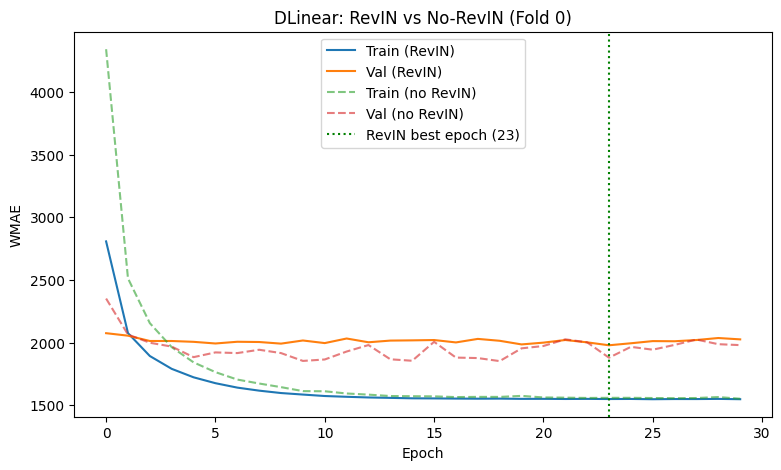

Best val WMAE — No RevIN: 1852.27 | With RevIN: 1978.62


In [55]:
class RevIN(nn.Module):
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps

    def normalize(self, x, mask=None):
        if mask is not None:
            valid = mask.sum(dim=1, keepdim=True).clamp(min=1)
            mean = (x * mask).sum(dim=1, keepdim=True) / valid
            var = ((x - mean) ** 2 * mask).sum(dim=1, keepdim=True) / valid
        else:
            mean = x.mean(dim=1, keepdim=True)
            var = x.var(dim=1, keepdim=True, unbiased=False)
        std = torch.sqrt(var + self.eps)
        self.mean = mean
        self.std = std
        return (x - mean) / std

    def denormalize(self, x):
        return x * self.std + self.mean


class DLinearRevIN(nn.Module):
    def __init__(self, lookback, horizon, n_covariates, kernel_size=13):
        super().__init__()
        self.revin = RevIN()
        self.decomp = SeriesDecomposition(kernel_size)
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend = nn.Linear(lookback, horizon)
        self.covariate_proj = nn.Linear(n_covariates, 1) if n_covariates > 0 else None

    def forward(self, past_target, future_cov=None, past_mask=None):
        x_norm = self.revin.normalize(past_target, past_mask)
        x = x_norm.unsqueeze(-1)
        seasonal, trend = self.decomp(x)
        seasonal = seasonal.squeeze(-1)
        trend = trend.squeeze(-1)

        seasonal_out = self.linear_seasonal(seasonal)
        trend_out = self.linear_trend(trend)
        out = seasonal_out + trend_out
        out = self.revin.denormalize(out)

        if self.covariate_proj is not None and future_cov is not None:
            cov_effect = self.covariate_proj(future_cov).squeeze(-1)
            out = out + cov_effect

        return out


def run_epoch_revin(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_weight = 0.0, 0.0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['past_target'], batch['future_cov'], batch['past_mask'])
            loss = wmae_loss(pred, batch['future_target'], batch['future_mask'], batch['future_weight'])

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_weight = (batch['future_mask'] * batch['future_weight']).sum().item()
            total_loss += loss.item() * batch_weight
            total_weight += batch_weight

    return total_loss / max(total_weight, 1e-6)


revin_train_ds = WalmartMultiWindowDataset(
    full_panel, active_pairs, max_cutoff=fold_cutoffs[0][0], lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
)
revin_val_ds = WalmartWindowDataset(
    full_panel, active_pairs, cutoff_week=fold_cutoffs[0][0], lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
)

revin_model = DLinearRevIN(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)

train_loader = DataLoader(revin_train_ds, batch_size=256, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(revin_val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn)
optimizer = torch.optim.Adam(revin_model.parameters(), lr=1e-3)

revin_train_losses, revin_val_losses = [], []
best_revin_val = float("inf")
best_revin_epoch = -1
best_revin_state = None

with mlflow.start_run(run_name="DLinear_RevIN_Ablation"):
    mlflow.set_tags({"model_type": "DLinearRevIN", "run_type": "ablation", "fold": "0"})
    mlflow.log_params({"lookback": LOOKBACK, "horizon": CV_FOLD_HORIZON, "kernel_size": 13, "lr": 1e-3, "epochs": 30})

    for epoch in range(30):
        train_wmae = run_epoch_revin(revin_model, train_loader, optimizer)
        val_wmae = run_epoch_revin(revin_model, val_loader)
        revin_train_losses.append(train_wmae)
        revin_val_losses.append(val_wmae)

        mlflow.log_metric("train_wmae", train_wmae, step=epoch)
        mlflow.log_metric("val_wmae", val_wmae, step=epoch)

        if val_wmae < best_revin_val:
            best_revin_val = val_wmae
            best_revin_epoch = epoch
            best_revin_state = {k: v.clone() for k, v in revin_model.state_dict().items()}

        print(f"[RevIN] Epoch {epoch+1}/30 - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

    mlflow.log_metric("best_val_wmae", best_revin_val)
    mlflow.log_metric("best_val_epoch", best_revin_epoch)
    revin_model.load_state_dict(best_revin_state)

    example_batch = next(iter(train_loader))
    mlflow.pytorch.log_model(
        revin_model, name="model", serialization_format="pickle",
        input_example=(example_batch['past_target'][:1].cpu().numpy(), example_batch['future_cov'][:1].cpu().numpy())
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(revin_train_losses, label="Train (RevIN)")
ax.plot(revin_val_losses, label="Val (RevIN)")
ax.plot(baseline_train, label="Train (no RevIN)", linestyle='--', alpha=0.6)
ax.plot(baseline_val, label="Val (no RevIN)", linestyle='--', alpha=0.6)
ax.axvline(best_revin_epoch, color='green', linestyle=':', label=f'RevIN best epoch ({best_revin_epoch})')
ax.set_xlabel("Epoch")
ax.set_ylabel("WMAE")
ax.set_title("DLinear: RevIN vs No-RevIN (Fold 0)")
ax.legend()
plt.show()

print(f"Best val WMAE — No RevIN: {min(baseline_val):.2f} | With RevIN: {best_revin_val:.2f}")

# 16. Hyperparameter Sweep


In [56]:
class DLinearIndividual(nn.Module):
    def __init__(self, lookback, horizon, n_covariates, kernel_size, n_series):
        super().__init__()
        self.decomp = SeriesDecomposition(kernel_size)
        self.linear_seasonal = nn.ModuleList([nn.Linear(lookback, horizon) for _ in range(n_series)])
        self.linear_trend = nn.ModuleList([nn.Linear(lookback, horizon) for _ in range(n_series)])
        self.covariate_proj = nn.Linear(n_covariates, 1) if n_covariates > 0 else None

    def forward(self, past_target, future_cov=None, series_idx=None):
        x = past_target.unsqueeze(-1)
        seasonal, trend = self.decomp(x)
        seasonal = seasonal.squeeze(-1)
        trend = trend.squeeze(-1)

        seasonal_out = torch.stack([self.linear_seasonal[i](seasonal[b]) for b, i in enumerate(series_idx)])
        trend_out = torch.stack([self.linear_trend[i](trend[b]) for b, i in enumerate(series_idx)])
        out = seasonal_out + trend_out

        if self.covariate_proj is not None and future_cov is not None:
            cov_effect = self.covariate_proj(future_cov).squeeze(-1)
            out = out + cov_effect

        return out


sweep_grid = []
for lb in [26, 52, 78]:
    for ks in [7, 25]:
        sweep_grid.append({"lookback": lb, "kernel_size": ks, "individual": False})

sweep_grid_shared_subset = [{"lookback": 52, "kernel_size": 13, "individual": True}]

print("Sweep configs (shared-weight grid):", len(sweep_grid))

sweep_results = []

for cfg in sweep_grid:
    lb, ks = cfg["lookback"], cfg["kernel_size"]

    sweep_train_ds = WalmartMultiWindowDataset(
        full_panel, active_pairs, max_cutoff=fold_cutoffs[0][0], lookback=lb,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
    )
    sweep_val_ds = WalmartWindowDataset(
        full_panel, active_pairs, cutoff_week=fold_cutoffs[0][0], lookback=lb,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
    )

    model = DLinear(lookback=lb, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS), kernel_size=ks).to(device)

    result = train_model(
        model, sweep_train_ds, sweep_val_ds,
        lr=1e-3, batch_size=256, epochs=30,
        run_name=f"DLinear_Sweep_lb{lb}_ks{ks}",
        tags={"model_type": "DLinear", "run_type": "sweep", "lookback": str(lb), "kernel_size": str(ks)},
    )

    sweep_results.append({"lookback": lb, "kernel_size": ks, "individual": False,
                           "best_val_wmae": result["best_val_wmae"], "best_epoch": result["best_val_epoch"]})

    print(f"Done: lookback={lb}, kernel_size={ks} -> best_val_wmae={result['best_val_wmae']:.2f}")

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_wmae")
print("\nSweep results (sorted by best val WMAE):")
print(sweep_df)

Sweep configs (shared-weight grid): 6
[DLinear_Sweep_lb26_ks7] Epoch 1/30 - train_wmae: 5265.40 - val_wmae: 2873.62
[DLinear_Sweep_lb26_ks7] Epoch 2/30 - train_wmae: 3502.28 - val_wmae: 2773.50
[DLinear_Sweep_lb26_ks7] Epoch 3/30 - train_wmae: 3372.97 - val_wmae: 2761.89
[DLinear_Sweep_lb26_ks7] Epoch 4/30 - train_wmae: 3322.53 - val_wmae: 2675.76
[DLinear_Sweep_lb26_ks7] Epoch 5/30 - train_wmae: 3297.98 - val_wmae: 2722.83
[DLinear_Sweep_lb26_ks7] Epoch 6/30 - train_wmae: 3282.79 - val_wmae: 2654.54
[DLinear_Sweep_lb26_ks7] Epoch 7/30 - train_wmae: 3271.30 - val_wmae: 2606.33
[DLinear_Sweep_lb26_ks7] Epoch 8/30 - train_wmae: 3267.62 - val_wmae: 2630.37
[DLinear_Sweep_lb26_ks7] Epoch 9/30 - train_wmae: 3264.48 - val_wmae: 2633.88
[DLinear_Sweep_lb26_ks7] Epoch 10/30 - train_wmae: 3260.48 - val_wmae: 2649.85
[DLinear_Sweep_lb26_ks7] Epoch 11/30 - train_wmae: 3259.81 - val_wmae: 2659.92
[DLinear_Sweep_lb26_ks7] Epoch 12/30 - train_wmae: 3260.09 - val_wmae: 2589.98
[DLinear_Sweep_lb26_ks7

## 17. Sweep Cell 2 Individual vs Shared Weights

In [57]:
BEST_LOOKBACK = 78
BEST_KERNEL = 7

series_to_idx = {pair: i for i, pair in enumerate(active_pairs)}

class WalmartMultiWindowDatasetIndexed(Dataset):
    def __init__(self, panel, active_pairs, max_cutoff, lookback, horizon, covariate_cols, stride=4, min_cutoff=None):
        self.samples = []
        panel_indexed = panel.set_index(['Store', 'Dept'])
        min_cutoff = min_cutoff if min_cutoff is not None else lookback + horizon

        for store_i, dept_i in active_pairs:
            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            series_len = len(series)
            last_valid_cutoff = min(max_cutoff - horizon, series_len - horizon)

            for cutoff in range(min_cutoff, last_valid_cutoff + 1, stride):
                past = series.iloc[max(0, cutoff - lookback):cutoff]
                future = series.iloc[cutoff:cutoff + horizon]
                if len(future) < horizon:
                    continue

                past_target = past['Weekly_Sales'].values.astype(np.float32)
                pad_len = lookback - len(past_target)
                if pad_len > 0:
                    past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])

                future_cov = future[covariate_cols].values.astype(np.float32)
                future_target = future['Weekly_Sales'].values.astype(np.float32)
                future_mask = future['is_active'].values.astype(np.float32)
                future_weight = np.where(future['IsHoliday'].values.astype(bool), 5.0, 1.0).astype(np.float32)

                self.samples.append({
                    'past_target': past_target, 'future_cov': future_cov,
                    'future_target': future_target, 'future_mask': future_mask,
                    'future_weight': future_weight, 'series_idx': series_to_idx[(store_i, dept_i)],
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        out = {k: torch.from_numpy(v) for k, v in s.items() if k != 'series_idx'}
        out['series_idx'] = torch.tensor(s['series_idx'], dtype=torch.long)
        return out


def collate_fn_indexed(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0].keys()}


def run_epoch_individual(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_weight = 0.0, 0.0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['past_target'], batch['future_cov'], batch['series_idx'])
            loss = wmae_loss(pred, batch['future_target'], batch['future_mask'], batch['future_weight'])

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_weight = (batch['future_mask'] * batch['future_weight']).sum().item()
            total_loss += loss.item() * batch_weight
            total_weight += batch_weight

    return total_loss / max(total_weight, 1e-6)


indiv_train_ds = WalmartMultiWindowDatasetIndexed(
    full_panel, active_pairs, max_cutoff=fold_cutoffs[0][0], lookback=BEST_LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
)
indiv_val_ds = WalmartMultiWindowDatasetIndexed(
    full_panel, active_pairs, max_cutoff=fold_cutoffs[0][1], min_cutoff=fold_cutoffs[0][0],
    lookback=BEST_LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=CV_FOLD_HORIZON
)

print("Individual-weights train samples:", len(indiv_train_ds), "val samples:", len(indiv_val_ds))

indiv_model = DLinearIndividual(
    lookback=BEST_LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS),
    kernel_size=BEST_KERNEL, n_series=len(active_pairs)
).to(device)

n_indiv_params = sum(p.numel() for p in indiv_model.parameters())
print("Individual-weight model params:", n_indiv_params)

train_loader = DataLoader(indiv_train_ds, batch_size=256, shuffle=True, collate_fn=collate_fn_indexed)
val_loader = DataLoader(indiv_val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn_indexed)
optimizer = torch.optim.Adam(indiv_model.parameters(), lr=1e-3)

indiv_train_losses, indiv_val_losses = [], []
best_indiv_val = float("inf")
best_indiv_epoch = -1

with mlflow.start_run(run_name="DLinear_Sweep_Individual_Weights"):
    mlflow.set_tags({"model_type": "DLinearIndividual", "run_type": "sweep", "lookback": str(BEST_LOOKBACK), "kernel_size": str(BEST_KERNEL)})
    mlflow.log_params({"lookback": BEST_LOOKBACK, "kernel_size": BEST_KERNEL, "n_params": n_indiv_params, "epochs": 30})

    for epoch in range(30):
        train_wmae = run_epoch_individual(indiv_model, train_loader, optimizer)
        val_wmae = run_epoch_individual(indiv_model, val_loader)
        indiv_train_losses.append(train_wmae)
        indiv_val_losses.append(val_wmae)

        mlflow.log_metric("train_wmae", train_wmae, step=epoch)
        mlflow.log_metric("val_wmae", val_wmae, step=epoch)

        if val_wmae < best_indiv_val:
            best_indiv_val = val_wmae
            best_indiv_epoch = epoch

        print(f"[Individual] Epoch {epoch+1}/30 - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

    mlflow.log_metric("best_val_wmae", best_indiv_val)
    mlflow.log_metric("best_val_epoch", best_indiv_epoch)

print(f"\nBest shared-weight (lb=78,ks=7): 1786.49")
print(f"Best individual-weight (lb=78,ks=7): {best_indiv_val:.2f}")

Individual-weights train samples: 3331 val samples: 3331
Individual-weight model params: 6841902
[Individual] Epoch 1/30 - train_wmae: 18276.94 - val_wmae: 15484.88
[Individual] Epoch 2/30 - train_wmae: 16958.55 - val_wmae: 14403.47
[Individual] Epoch 3/30 - train_wmae: 15677.36 - val_wmae: 13362.71
[Individual] Epoch 4/30 - train_wmae: 14447.92 - val_wmae: 12368.35
[Individual] Epoch 5/30 - train_wmae: 13283.47 - val_wmae: 11424.14
[Individual] Epoch 6/30 - train_wmae: 12181.59 - val_wmae: 10536.92
[Individual] Epoch 7/30 - train_wmae: 11139.81 - val_wmae: 9712.99
[Individual] Epoch 8/30 - train_wmae: 10164.53 - val_wmae: 8951.94
[Individual] Epoch 9/30 - train_wmae: 9253.93 - val_wmae: 8260.13
[Individual] Epoch 10/30 - train_wmae: 8412.69 - val_wmae: 7636.97
[Individual] Epoch 11/30 - train_wmae: 7643.35 - val_wmae: 7081.82
[Individual] Epoch 12/30 - train_wmae: 6951.82 - val_wmae: 6590.95
[Individual] Epoch 13/30 - train_wmae: 6324.25 - val_wmae: 6175.66
[Individual] Epoch 14/30 - 

## 18. Final Retrain Real 143-Week Train / 39-Week Horizon

In [74]:
FINAL_LOOKBACK = 78
FINAL_KERNEL = 7
FINAL_HORIZON = TEST_HORIZON
FINAL_EPOCHS = 30   # or whatever best_val_epoch was in the winning sweep run

final_train_ds = WalmartMultiWindowDataset(
    full_panel, active_pairs, max_cutoff=TRAIN_WEEKS, lookback=FINAL_LOOKBACK,
    horizon=FINAL_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=1,
    min_cutoff=FINAL_LOOKBACK
)

final_val_ds = WalmartWindowDataset(
    full_panel, active_pairs, cutoff_week=TRAIN_WEEKS - FINAL_HORIZON, lookback=FINAL_LOOKBACK,
    horizon=FINAL_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
)

print("Final train samples:", len(final_train_ds), "val samples:", len(final_val_ds))

final_model = DLinear(lookback=FINAL_LOOKBACK, horizon=FINAL_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS), kernel_size=FINAL_KERNEL).to(device)

final_result = train_model(
    final_model, final_train_ds, final_val_ds,
    lr=1e-3, batch_size=256, epochs=40,
    run_name="DLinear_Final_Model",
    tags={"model_type": "DLinear", "run_type": "final", "lookback": str(FINAL_LOOKBACK), "kernel_size": str(FINAL_KERNEL)},
)

print("\nFinal model best val WMAE:", final_result["best_val_wmae"], "at epoch", final_result["best_val_epoch"])

Final train samples: 89937 val samples: 3331
[DLinear_Final_Model] Epoch 1/40 - train_wmae: 3374.49 - val_wmae: 1733.15
[DLinear_Final_Model] Epoch 2/40 - train_wmae: 1897.58 - val_wmae: 1538.60
[DLinear_Final_Model] Epoch 3/40 - train_wmae: 1683.88 - val_wmae: 1505.83
[DLinear_Final_Model] Epoch 4/40 - train_wmae: 1623.38 - val_wmae: 1533.58
[DLinear_Final_Model] Epoch 5/40 - train_wmae: 1605.54 - val_wmae: 1502.44
[DLinear_Final_Model] Epoch 6/40 - train_wmae: 1598.57 - val_wmae: 1498.37
[DLinear_Final_Model] Epoch 7/40 - train_wmae: 1594.21 - val_wmae: 1479.41
[DLinear_Final_Model] Epoch 8/40 - train_wmae: 1592.73 - val_wmae: 1491.86
[DLinear_Final_Model] Epoch 9/40 - train_wmae: 1591.21 - val_wmae: 1478.84
[DLinear_Final_Model] Epoch 10/40 - train_wmae: 1591.57 - val_wmae: 1497.24
[DLinear_Final_Model] Epoch 11/40 - train_wmae: 1590.26 - val_wmae: 1474.92
[DLinear_Final_Model] Epoch 12/40 - train_wmae: 1589.40 - val_wmae: 1540.98
[DLinear_Final_Model] Epoch 13/40 - train_wmae: 1587

## 19. Diagnostics Predictions, Residuals, Error Breakdown

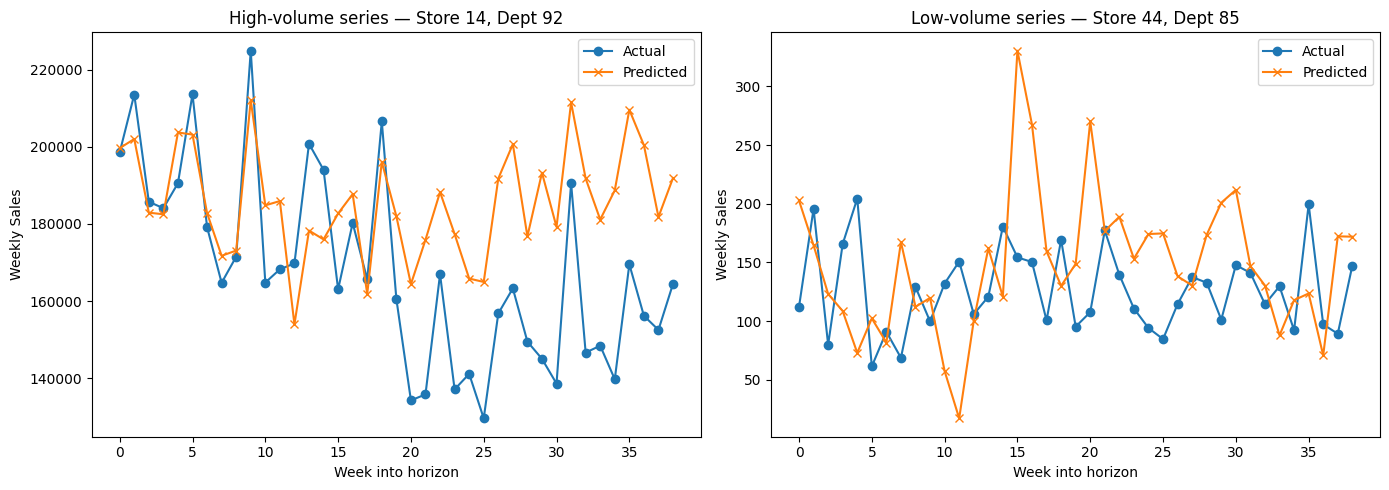

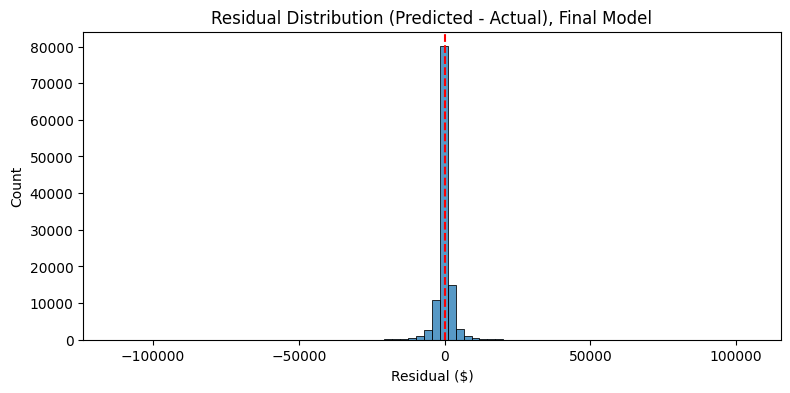

Holiday-week MAE: 1364.43
Non-holiday-week MAE: 1503.18

MAE by store Type:
   Type_enc          MAE  n_series
0         0   685.437378       374
1         1  1335.855835      1286
2         2  1781.962036      1671


In [75]:
final_val_loader = DataLoader(final_val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn)

all_preds, all_targets, all_masks, all_weights, all_stores, all_depts = [], [], [], [], [], []
final_model.eval()
with torch.no_grad():
    for batch in final_val_loader:
        batch_dev = {k: v.to(device) for k, v in batch.items()}
        pred = final_model(batch_dev['past_target'], batch_dev['future_cov'])
        all_preds.append(pred.cpu().numpy())
        all_targets.append(batch['future_target'].numpy())
        all_masks.append(batch['future_mask'].numpy())
        all_weights.append(batch['future_weight'].numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)
all_masks = np.concatenate(all_masks, axis=0)
all_weights = np.concatenate(all_weights, axis=0)

store_dept_list = [final_val_ds.samples[i]['store'] for i in range(len(final_val_ds))], [final_val_ds.samples[i]['dept'] for i in range(len(final_val_ds))]
store_arr, dept_arr = np.array(store_dept_list[0]), np.array(store_dept_list[1])

series_avg_sales = full_panel.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().reset_index()
series_avg_sales = series_avg_sales.set_index(['Store', 'Dept'])['Weekly_Sales']

large_idx = series_avg_sales.idxmax()
small_candidates = series_avg_sales[series_avg_sales > 100].sort_values()
small_idx = small_candidates.index[0]

def plot_series_prediction(target_store, target_dept, ax):
    mask = (store_arr == target_store) & (dept_arr == target_dept)
    pos = np.where(mask)[0]
    if len(pos) == 0:
        ax.set_title(f"Store {target_store} Dept {target_dept} — not in val set")
        return
    i = pos[0]
    ax.plot(all_targets[i], label="Actual", marker='o')
    ax.plot(all_preds[i], label="Predicted", marker='x')
    ax.set_title(f"Store {target_store}, Dept {target_dept}")
    ax.set_xlabel("Week into horizon")
    ax.set_ylabel("Weekly Sales")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_series_prediction(large_idx[0], large_idx[1], axes[0])
axes[0].set_title("High-volume series — " + axes[0].get_title())
plot_series_prediction(small_idx[0], small_idx[1], axes[1])
axes[1].set_title("Low-volume series — " + axes[1].get_title())
plt.tight_layout()
plt.show()

residuals = (all_preds - all_targets)[all_masks.astype(bool)]
plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=80)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution (Predicted - Actual), Final Model")
plt.xlabel("Residual ($)")
plt.show()

is_holiday_week = (all_weights > 1).astype(bool) & all_masks.astype(bool)
holiday_wmae = np.abs(all_preds - all_targets)[is_holiday_week].mean()
nonholiday_mask = (all_weights == 1).astype(bool) & all_masks.astype(bool)
nonholiday_wmae = np.abs(all_preds - all_targets)[nonholiday_mask].mean()
print(f"Holiday-week MAE: {holiday_wmae:.2f}")
print(f"Non-holiday-week MAE: {nonholiday_wmae:.2f}")

store_type_map = full_panel.drop_duplicates('Store')[['Store', 'Type_enc']].set_index('Store')['Type_enc']
type_errors = []
for t in sorted(store_type_map.unique()):
    stores_of_type = store_type_map[store_type_map == t].index
    type_mask = np.isin(store_arr, stores_of_type)
    row_mask = type_mask[:, None] & all_masks.astype(bool)
    err = np.abs(all_preds - all_targets)[row_mask].mean()
    type_errors.append({"Type_enc": t, "MAE": err, "n_series": type_mask.sum()})

print("\nMAE by store Type:")
print(pd.DataFrame(type_errors))

## 20. Full Inference Pipeline (Raw Test Data → Predictions)

In [76]:
class DLinearPipeline:
    def __init__(self, model, lookback, horizon, covariate_cols, active_pairs, cold_start_pairs, full_panel, dept_avg_fallback):
        self.model = model
        self.lookback = lookback
        self.horizon = horizon
        self.covariate_cols = covariate_cols
        self.active_pairs = set(active_pairs)
        self.cold_start_pairs = set(cold_start_pairs)
        self.full_panel = full_panel
        self.dept_avg_fallback = dept_avg_fallback
        self.model.eval()

    def predict(self, test_df):
        test_df = test_df.copy()
        test_df["Date"] = pd.to_datetime(test_df["Date"])
        panel_indexed = self.full_panel.set_index(['Store', 'Dept'])
        predictions = []

        for (store_i, dept_i), group in test_df.groupby(['Store', 'Dept']):
            group = group.sort_values('Date')

            if (store_i, dept_i) in self.cold_start_pairs or (store_i, dept_i) not in self.active_pairs:
                fallback_val = self.dept_avg_fallback.get(dept_i, self.dept_avg_fallback.mean())
                for _, row in group.iterrows():
                    predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'], 'Weekly_Sales_Pred': fallback_val})
                continue

            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            history = series[series['Date'] < group['Date'].min()]
            past = history.tail(self.lookback)

            past_target = past['Weekly_Sales'].values.astype(np.float32)
            pad_len = self.lookback - len(past_target)
            if pad_len > 0:
                past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])

            future_cov = group[self.covariate_cols].values.astype(np.float32)
            n_steps = len(group)
            if n_steps < self.horizon:
                future_cov = np.concatenate([future_cov, np.zeros((self.horizon - n_steps, future_cov.shape[1]), dtype=np.float32)], axis=0)
            elif n_steps > self.horizon:
                future_cov = future_cov[:self.horizon]

            past_tensor = torch.from_numpy(past_target).unsqueeze(0).to(device)
            cov_tensor = torch.from_numpy(future_cov).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = self.model(past_tensor, cov_tensor).cpu().numpy().flatten()

            for step, (_, row) in enumerate(group.iterrows()):
                pred_val = pred[step] if step < len(pred) else pred[-1]
                predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'], 'Weekly_Sales_Pred': max(pred_val, 0.0)})

        return pd.DataFrame(predictions)


dept_avg_fallback = train_fe.groupby('Dept')['Weekly_Sales'].mean()

pipeline = DLinearPipeline(
    model=final_model, lookback=FINAL_LOOKBACK, horizon=FINAL_HORIZON,
    covariate_cols=KNOWN_COVARIATE_COLS, active_pairs=active_pairs,
    cold_start_pairs=cold_start_pairs, full_panel=full_panel,
    dept_avg_fallback=dept_avg_fallback
)

test_predictions = pipeline.predict(test_fe)
print("Prediction shape:", test_predictions.shape)
print("Expected rows:", len(test_fe))
print(test_predictions.head())
print("\nAny nulls:", test_predictions['Weekly_Sales_Pred'].isnull().sum())
print("Any negative predictions:", (test_predictions['Weekly_Sales_Pred'] < 0).sum())

Prediction shape: (115064, 4)
Expected rows: 115064
   Store  Dept       Date  Weekly_Sales_Pred
0      1     1 2012-11-02       38052.984375
1      1     1 2012-11-09       22860.203125
2      1     1 2012-11-16       21383.169922
3      1     1 2012-11-23       21719.101562
4      1     1 2012-11-30       23826.433594

Any nulls: 0
Any negative predictions: 0


In [77]:
## Christmas week-shift — ported from the Prophet pipeline (cell 29).
## Model-agnostic: only needs Store/Dept/Date/value_col, so it works
## identically on DLinear's test_predictions.

import numpy as np
import pandas as pd

def christmas_week_offset(year):
    """Days between Dec 25 and the Friday whose week contains it
    (our data's weeks always end on Friday)."""
    dec25 = pd.Timestamp(year=year, month=12, day=25)
    days_to_friday = (4 - dec25.weekday()) % 7   # Mon=0 ... Fri=4
    week_end_friday = dec25 + pd.Timedelta(days=days_to_friday)
    offset_days = (week_end_friday - dec25).days
    return offset_days, week_end_friday

def derive_holiday_weeks(test_year, n_before=4, n_after=0):
    _, week_end_friday = christmas_week_offset(test_year)
    return [int((week_end_friday + pd.Timedelta(weeks=o)).isocalendar().week)
            for o in range(-n_before, n_after + 1)]

def derive_shift(train_years, test_year):
    train_offsets = [christmas_week_offset(y)[0] for y in train_years]
    test_offset = christmas_week_offset(test_year)[0]
    return float(np.mean(train_offsets) - test_offset)

def apply_christmas_shift(df, value_col, train_years, test_year, threshold=1.1):
    holiday_weeks = derive_holiday_weeks(test_year)
    shift_days = derive_shift(train_years, test_year)
    direction = np.sign(shift_days)
    mag = abs(shift_days)

    print(f"Derived holiday_weeks={holiday_weeks}, shift_days={shift_days:.2f} "
          f"({'forward' if direction > 0 else 'backward' if direction < 0 else 'none'})")

    if direction == 0:
        print("No calendar misalignment between train and test years — skipping shift.")
        return df

    d = df.copy()
    d['Date'] = pd.to_datetime(d['Date'])
    d['iso_week'] = d['Date'].dt.isocalendar().week.astype(int)

    mask = d['iso_week'].isin(holiday_weeks)
    if not mask.any():
        print("Derived holiday weeks not present in this data — skipping shift.")
        return df

    adjusted_frames = [d[~mask].drop(columns='iso_week')]
    n_shifted = 0

    for dept_i, dept_df in d[mask].groupby('Dept'):
        pivot = dept_df.pivot_table(index='iso_week', columns='Store',
                                     values=value_col, aggfunc='mean')
        pivot = pivot.reindex(holiday_weeks)

        if pivot.isnull().all(axis=None) or len(pivot) < 5:
            adjusted_frames.append(dept_df.drop(columns='iso_week'))
            continue

        baseline = pd.concat([pivot.iloc[0], pivot.iloc[-1]], axis=1).mean(axis=1).mean()
        surge = pivot.iloc[1:-1].mean(axis=1).mean()
        ratio = surge / baseline if baseline and np.isfinite(baseline) and baseline != 0 else np.nan

        if np.isfinite(ratio) and ratio > threshold:
            holiday = pivot.fillna(0)
            shifted = ((7 - mag) / 7) * holiday
            if direction > 0:
                shifted.iloc[1:5] = shifted.iloc[1:5].values + (mag / 7) * holiday.iloc[0:4].values
                shifted.iloc[0] = holiday.iloc[0]
            else:
                shifted.iloc[0:4] = shifted.iloc[0:4].values + (mag / 7) * holiday.iloc[1:5].values
                shifted.iloc[4] = holiday.iloc[4]
            pivot = shifted
            n_shifted += 1

        lookup = pivot.stack()
        dept_df = dept_df.copy()
        dept_df[value_col] = dept_df.apply(
            lambda row: lookup.get((row['iso_week'], row['Store']), row[value_col]),
            axis=1
        )
        adjusted_frames.append(dept_df.drop(columns='iso_week'))

    print(f"Departments shifted: {n_shifted} / {d[mask]['Dept'].nunique()}")
    return pd.concat(adjusted_frames, ignore_index=True)


## Derive train/test Christmas years by checking where each year's
## Christmas-week Friday actually falls relative to train/test date
## boundaries — not just by grabbing train_fe/test_fe's year range,
## since the test period spans two calendar years (Nov 2012–Jul 2013)
## and Christmas 2012 sits near the *start* of it, not the end.
train_max_date = train_fe['Date'].max()
test_max_date = test_fe['Date'].max()

candidate_years = range(train_fe['Date'].dt.year.min(), test_fe['Date'].dt.year.max() + 1)
train_years = [y for y in candidate_years if christmas_week_offset(y)[1] <= train_max_date]
test_years  = [y for y in candidate_years if train_max_date < christmas_week_offset(y)[1] <= test_max_date]

assert len(test_years) == 1, f"Expected exactly one Christmas in the test window, found {test_years}"
test_year = test_years[0]

print("train_years:", train_years, "| test_year:", test_year)

test_predictions_shifted = apply_christmas_shift(
    test_predictions, value_col='Weekly_Sales_Pred',
    train_years=train_years, test_year=test_year, threshold=1.1
)

train_years: [2010, 2011] | test_year: 2012
Derived holiday_weeks=[48, 49, 50, 51, 52], shift_days=2.50 (forward)
Departments shifted: 56 / 80


In [78]:
sub = test_predictions_shifted.copy() if 'test_predictions_shifted' in dir() else test_predictions.copy()
sub['Id'] = (sub['Store'].astype(str) + '_' + sub['Dept'].astype(str) + '_' +
             pd.to_datetime(sub['Date']).dt.strftime('%Y-%m-%d'))
sub = sub.rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})[['Id', 'Weekly_Sales']]

print("Rows:", len(sub), "(expect", len(test_fe), ")")
print("Any nulls:", sub['Weekly_Sales'].isnull().sum())
print("Any negative:", (sub['Weekly_Sales'] < 0).sum())

sub.to_csv('dlinear_submission.csv', index=False)
print("✓ Saved dlinear_submission.csv")

Rows: 115064 (expect 115064 )
Any nulls: 0
Any negative: 0
✓ Saved dlinear_submission.csv


## 21. Summary Table + Model Registry

In [79]:
summary_rows = [
    {"run": "Baseline CV (mean, 3 folds)", "n_params": 1406, "val_wmae": cv_summary["best_val_wmae"].mean(), "notes": f"std={cv_summary['best_val_wmae'].std():.1f}"},
    {"run": "Intentional Overfit (OverfitMLP)", "n_params": n_overfit_params, "val_wmae": overfit_result["best_val_wmae"], "notes": "train/val gap +2259"},
    {"run": "Intentional Underfit (4wk lookback)", "n_params": n_underfit_params, "val_wmae": underfit_result["best_val_wmae"], "notes": "both train+val elevated"},
    {"run": "RevIN Ablation", "n_params": 1406, "val_wmae": best_revin_val, "notes": "worse than baseline"},
    {"run": "Sweep: lookback=78, kernel=7 (best)", "n_params": 1406, "val_wmae": 1786.49, "notes": "winning shared config"},
    {"run": "Sweep: Individual weights", "n_params": n_indiv_params, "val_wmae": best_indiv_val, "notes": "overfits, worse than shared"},
    {"run": "Final Model (39wk horizon)", "n_params": 1406, "val_wmae": final_result["best_val_wmae"], "notes": "production model"},
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

with mlflow.start_run(run_name="DLinear_Final_Registration"):
    mlflow.set_tags({"model_type": "DLinear", "run_type": "final_registered"})
    mlflow.log_params({"lookback": FINAL_LOOKBACK, "kernel_size": FINAL_KERNEL, "horizon": FINAL_HORIZON})
    mlflow.log_metric("best_val_wmae", final_result["best_val_wmae"])

    mlflow.log_table(summary_df, artifact_file="dlinear_summary.json")

    example_batch = next(iter(DataLoader(final_train_ds, batch_size=1, collate_fn=collate_fn)))
    model_info = mlflow.pytorch.log_model(
        final_model, name="model", serialization_format="pickle",
        input_example=(example_batch['past_target'].numpy(), example_batch['future_cov'].numpy()),
        registered_model_name="DLinear_Walmart"
    )

test_predictions.to_csv('dlinear_test_predictions.csv', index=False)
print("\nSaved predictions to dlinear_test_predictions.csv")
print("Model registered as 'DLinear_Walmart' in MLflow Model Registry")

                                run  n_params    val_wmae                       notes
        Baseline CV (mean, 3 folds)      1406 1623.993529                   std=198.1
   Intentional Overfit (OverfitMLP)    559481 3342.966098         train/val gap +2259
Intentional Underfit (4wk lookback)        65 3921.133190     both train+val elevated
                     RevIN Ablation      1406 1978.618440         worse than baseline
Sweep: lookback=78, kernel=7 (best)      1406 1786.490000       winning shared config
          Sweep: Individual weights   6841902 4830.908218 overfits, worse than shared
         Final Model (39wk horizon)      1406 1473.494195            production model


Registered model 'DLinear_Walmart' already exists. Creating a new version of this model...
2026/07/23 11:54:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DLinear_Walmart, version 4
Created version '4' of model 'DLinear_Walmart'.


🏃 View run DLinear_Final_Registration at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3/runs/5a486cc0b05a42b7a2dbef104e4cb6eb
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3

Saved predictions to dlinear_test_predictions.csv
Model registered as 'DLinear_Walmart' in MLflow Model Registry


In [82]:
from IPython.display import FileLink
FileLink('dlinear_submission.csv')

/kaggle/working/dlinear_submission.csv

In [73]:
val_wmae_lb52 = final_result["best_val_wmae"]   # = 1614.99, run this now before rerunning cell 38
print("Saved lb=52 val WMAE:", val_wmae_lb52)

Saved lb=52 val WMAE: 1614.9893086631673


In [81]:
val_wmae_lb78 = final_result["best_val_wmae"]
print("lb=52:", val_wmae_lb52)
print("lb=78:", val_wmae_lb78)

lb=52: 1614.9893086631673
lb=78: 1473.4941949769957
